<a href="https://colab.research.google.com/github/Nurdaylight/A-Karpathy-repl/blob/main/PS2/PS2_empirical.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import necessary packages
import pandas as pd
import numpy as np

In [2]:

ps2_data = pd.read_stata("http://fmwww.bc.edu/ec-p/data/Hayashi/nerlove63.dta")

print(ps2_data.head(3))

   totcost  output  plabor      pfuel   pkap
0    0.082     2.0    2.09  17.900000  183.0
1    0.661     3.0    2.05  35.099998  174.0
2    0.990     4.0    2.05  35.099998  171.0


In [3]:
ps2_data=np.log(ps2_data)
ps2_data['const'] = 1

In [4]:
ps2_data.head(3)

,totcost,output,plabor,pfuel,pkap,const
0,-2.501036,0.693147,0.737164,2.884801,5.209486,1
1,-0.414001,1.098612,0.717840,3.558201,5.159055,1
2,-0.010050,1.386294,0.717840,3.558201,5.141664,1


In [45]:
X = ps2_data.iloc[:, 1:].to_numpy()          # shape: (n, k)
Y = ps2_data.iloc[:, 0].to_numpy().reshape(-1, 1)
ps2_data.iloc[:, 3][:4]

,pfuel
0,2.884801
1,3.558201
2,3.558201
3,3.471967


In [6]:
XtX_inv=np.linalg.inv(X.T@X)
estim1=XtX_inv@X.T@Y
out1=np.round(estim1,2)
out1

array([[ 0.72],
       [ 0.44],
       [ 0.43],
       [-0.22],
       [-3.53]])

In [15]:
e=Y-X@estim1
Var__estim1 = ((e.T @ e) / (140))[0] * XtX_inv
se_estim1= np.sqrt(np.diag(Var__estim1)).reshape(-1, 1)
se_estim1

array([[0.01746644],
       [0.29104763],
       [0.10036915],
       [0.33942852],
       [1.7743661 ]])

In [57]:
X2=(X[:,1:4]-X[:,2].reshape(-1, 1))
X2[:,1]+=1
X2=np.column_stack([X2, X[:, 0]])
Y2=Y-X[:,2].reshape(-1, 1)

In [59]:
#restricted regression
XtX2_inv=np.linalg.inv(X2.T@X2)
estim2=XtX2_inv@X2.T@Y2
out2=np.round(estim2,3)
out2

array([[ 0.593],
       [-4.691],
       [-0.007],
       [ 0.721]])

In [61]:
#restricted STD
e2=Y2-X2@estim2
Var__estim2 = ((e2.T @ e2) / (141))[0] * XtX2_inv
se_estim2= np.sqrt(np.diag(Var__estim2)).reshape(-1, 1)
se_estim2

array([[0.20457213],
       [0.88487119],
       [0.19073556],
       [0.01743572]])

In [130]:
bstp=[]
for _ in range(10000):
  #bootstrap estimates
  n = len(X2)
  k = 145  # number of samples

  idx = np.random.choice(n, size=k, replace=True)

  X_sample = X2[idx]
  Y_sample = Y2[idx]


  b=np.linalg.inv(X_sample.T@X_sample)@X_sample.T@Y_sample
  bstp.append(b)


In [131]:
M = np.hstack(bstp).T
print((np.var(M, axis=0, ddof=1)**0.5))
print(se_estim2.T)
print(np.mean(M, axis=0))


[0.1699272  0.82016824 0.15626781 0.03314965]
[[0.20457213 0.88487119 0.19073556 0.01743572]]
[ 5.89021272e-01 -4.73372940e+00 -1.76930678e-03  7.23610140e-01]


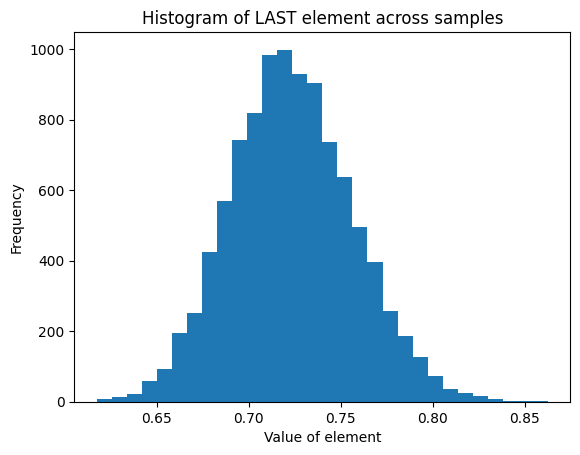

In [141]:
import matplotlib.pyplot as plt

# assume array is called A
first_elements = M[:, 3]

plt.hist(first_elements, bins=30)
plt.xlabel("Value of element")
plt.ylabel("Frequency")
plt.title("Histogram of LAST element across samples")
plt.show()

In [100]:
len(X2)

145